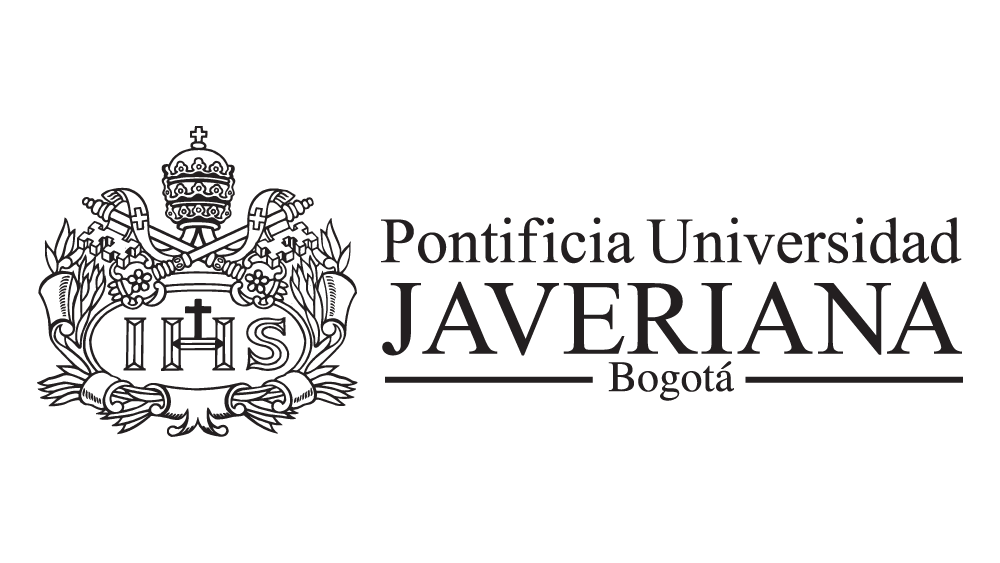

**Author:** Juan Felipe Gómez López

**Role:** Aspiring ML engineer - AI engineer - Student at Universidad Javeriana

**Objective:** Understand de basics of PySpark by working with the iris dataset.


# Apache Spark - Beginner Tutorial

Firstly, Thank you for checking this tutorial notebook. By now you must have read a lot about Apache Spark and its ML Library.So, I won't bore you with the introduction to Apache-Spark or even the library details. We shall move straight to the interesting stuff i.e. coding.

In this tuorial notebook we will try to compare some of the Apache Spark's Classification Algorithms in an easy way to make predictions. And since this is a beginner's tutorial, we will use the Iris Flower Dataset aka the beginner's dataset in machine learning.

**A quick summary:**

* Import Libraries
* Build Spark Session
* Data Load
* Data Exploration & Preparation
* Feature Engineering
* Data Scaling
* Data Split
* Build, Train & Evaluate Model


In [1]:
#install Apache Spark
!pip install pyspark --quiet

## Importing Libraries

In [2]:
#Generic Libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

#Apache Spark Libraries
import pyspark
from pyspark.sql import SparkSession

#Apache Spark ML CLassifier Libraries
from pyspark.ml.classification import DecisionTreeClassifier,RandomForestClassifier,NaiveBayes

#Apache Spark Evaluation Library
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

#Apache Spark Features libraries
from pyspark.ml.feature import StandardScaler,StringIndexer, VectorAssembler, VectorIndexer, OneHotEncoder

#Apache Spark Pipelin Library
from pyspark.ml import Pipeline

# Apache Spark `DenseVector`
from pyspark.ml.linalg import DenseVector

#Data Split Libraries
import sklearn
from sklearn.model_selection import train_test_split


#Tabulating Data
from tabulate import tabulate

#Garbage
import gc

pip install pyspark desacopla e instala las librerías comprimidas en el .jar de Apache Spark (incluyendo spark-core, spark-sql, spark-mllib) junto con los bindings de Python en el directorio de librerías del sistema.

## Build Spark Session

In [3]:
#Building Spark Session
spark = (SparkSession.builder
                  .appName('Apache Spark Beginner Tutorial')
                  .config("spark.executor.memory", "1G")
                  .config("spark.executor.cores","4")
                  .getOrCreate())

In [4]:
spark.sparkContext.setLogLevel('INFO')

In [5]:
spark.version

'4.0.4'

SparkSession.builder crea un objeto compilador en Python. Al invocar .getOrCreate(), PySpark levanta en background el puerto del bridge Py4J.  

La JVM del Driver instanciará un único SparkContext.  Se pasa la configuración de recursos: spark.executor.memory = 1G delimita el tamaño máximo del Heap de la JVM de los ejecutores, y spark.executor.cores = 4 reserva 4 hilos de procesamiento por proceso ejecutor.  El Driver contacta al Cluster Manager para reservar los slots e instanciar las JVM de trabajo en el clúster





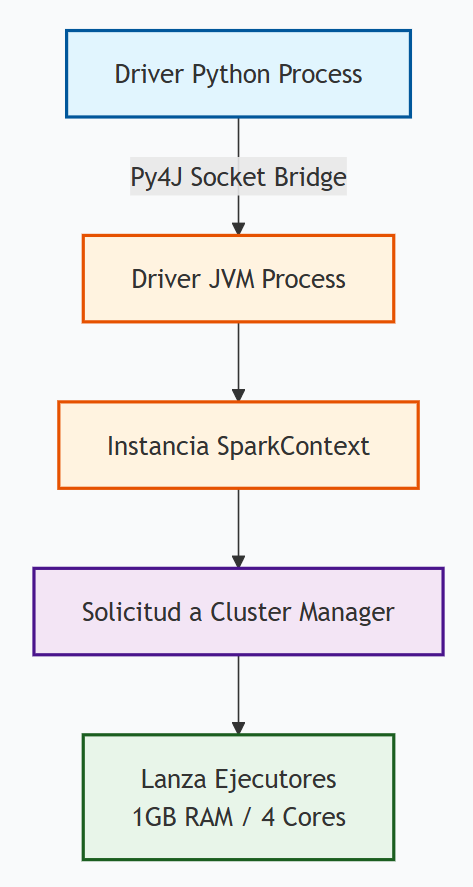

## Data Load

In [6]:
import pandas as pd

# Descargar el archivo a una ubicación temporal accesible por Spark
# Esto asegura que el archivo esté disponible localmente en el entorno de Colab
!mkdir -p /tmp/iris-dataset
!wget -nc -P /tmp/iris-dataset https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv

# Actualizar la URL para apuntar al archivo local con el prefijo 'file:'
url = 'file:/tmp/iris-dataset/iris.csv'

data = spark.read.format("csv") \
       .option("header", "true") \
       .option("inferSchema","true")\
       .load(url)

data.cache() #for faster re-use

--2026-09-19 18:49:02--  https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3858 (3.8K) [text/plain]
Saving to: ‘/tmp/iris-dataset/iris.csv’

iris.csv            100%[===================>]   3.77K  --.-KB/s    in 0s      

2026-09-19 18:49:02 (55.1 MB/s) - ‘/tmp/iris-dataset/iris.csv’ saved [3858/3858]



DataFrame[sepal_length: double, sepal_width: double, petal_length: double, petal_width: double, species: string]

inferSchema="true": No es completamente Lazy Evaluation, ya que para determinar si los campos son enteros, flotantes o cadenas, Spark se ve obligado a ejecutar un Job interno. Lee una porción o la totalidad del archivo CSV inspeccionando los valores línea por línea para construir el StructType del DataFrame.  

data.cache(): Marca las particiones del DataFrame en el DAG para ser mantenidas en la memoria de los ejecutores. No carga los datos inmediatamente sino que espera a que se ejecute la primera Acción de usuario.

## Data Exploration & Preparation

In [7]:
#Total records
data.count()

150

data.count es la primera acción del cuaderno. El Driver evalúa el DAG acumulado y detecta la instrucción .cache().  Genera un Job formado por 1 Stage.  Cada Task lee su partición correspondiente del CSV, la parsea a filas estructuradas, las persiste en el Storage Memory de la JVM del Executor y retorna el conteo parcial de filas al Driver.  El Driver suma los recuentos parciales y devuelve 150.

In [8]:
#Data Type
data.printSchema()

root
 |-- sepal_length: double (nullable = true)
 |-- sepal_width: double (nullable = true)
 |-- petal_length: double (nullable = true)
 |-- petal_width: double (nullable = true)
 |-- species: string (nullable = true)



Aquí miramos cada columna y su tipo de dato para conocer más del dataset y las features.

In [9]:
#Display records
data.show(5)

+------------+-----------+------------+-----------+-------+
|sepal_length|sepal_width|petal_length|petal_width|species|
+------------+-----------+------------+-----------+-------+
|         5.1|        3.5|         1.4|        0.2| setosa|
|         4.9|        3.0|         1.4|        0.2| setosa|
|         4.7|        3.2|         1.3|        0.2| setosa|
|         4.6|        3.1|         1.5|        0.2| setosa|
|         5.0|        3.6|         1.4|        0.2| setosa|
+------------+-----------+------------+-----------+-------+
only showing top 5 rows


In [10]:
#Records per Species
data.groupBy('species').count().show()

+----------+-----+
|   species|count|
+----------+-----+
| virginica|   50|
|versicolor|   50|
|    setosa|   50|
+----------+-----+



- Stage 0: Como los datos ya están cacheados en memoria RAM, cada Task lee las filas en su nodo y realiza un agrupamiento parcial local sumando las especies dentro de su propia partición. Posteriormente, escribe los resultados parciales agrupados en archivos de Shuffle local en disco.  

- Shuffle Exchange: Se redistribuyen los registros por clave: todas las especies "setosa" van a la Partición 0, "versicolor" a la Partición 1, y "virginica" a la Partición 2.  

- Stage 1: Las Tasks del nuevo Stage descargan los bloques por red (Shuffle Read), completan la suma final del conteo y la acción .show() envía las 5 primeras filas legibles de vuelta a la consola del Driver.


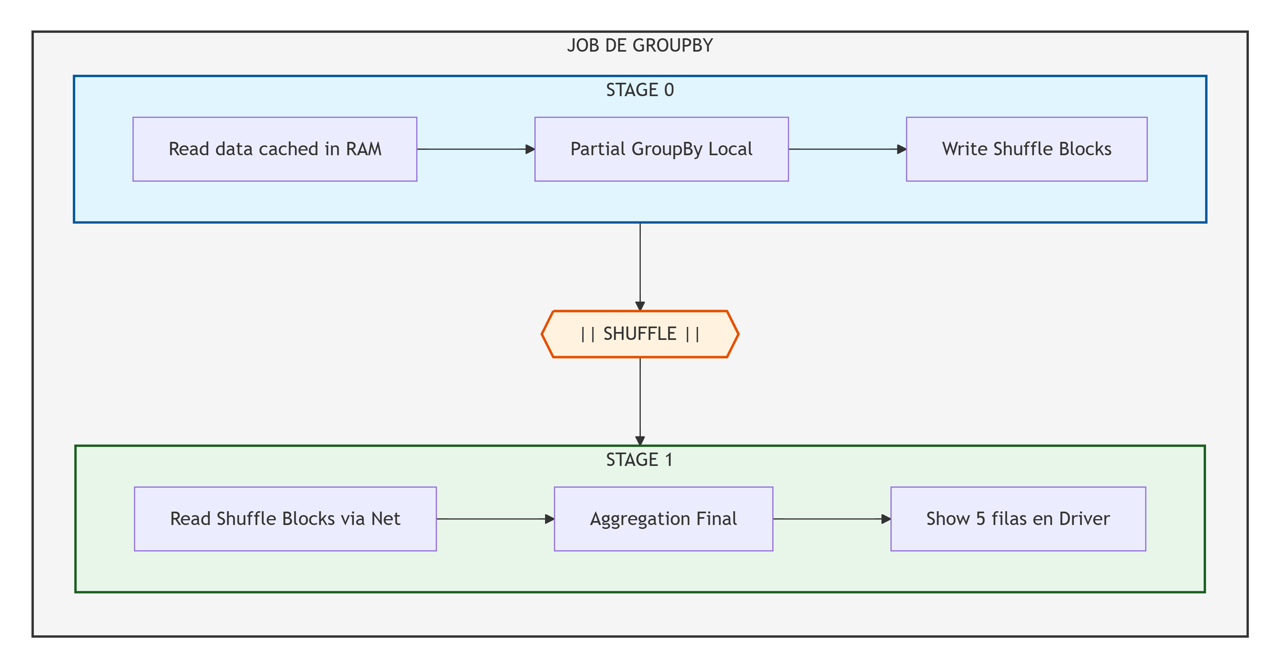

In [11]:
#Dataset Summary Stats
data.describe().show()

+-------+------------------+-------------------+------------------+------------------+---------+
|summary|      sepal_length|        sepal_width|      petal_length|       petal_width|  species|
+-------+------------------+-------------------+------------------+------------------+---------+
|  count|               150|                150|               150|               150|      150|
|   mean| 5.843333333333335|  3.057333333333334|3.7580000000000027| 1.199333333333334|     NULL|
| stddev|0.8280661279778637|0.43586628493669793|1.7652982332594662|0.7622376689603467|     NULL|
|    min|               4.3|                2.0|               1.0|               0.1|   setosa|
|    max|               7.9|                4.4|               6.9|               2.5|virginica|
+-------+------------------+-------------------+------------------+------------------+---------+



Al ejecutar data.describe().show(), la llamada .describe() define qué métricas calcular y genera el plan, mientras que la acción .show() dispara la ejecución en Spark. A continuación se detalla qué ocurre específicamente en cada etapa:

Al invocar .show(), el Driver dispara un Spark Job que asigna tasks a los Executors. En el Stage 0, cada tarea lee de forma independiente las filas que tiene en sus particiones locales de memoria o disco y procesa únicamente sobre su bloque de datos los conteos parciales, sumas parciales, sumas cuadráticas parciales, así como los mínimos y máximos locales de cada columna.


Debido a que la media y la desviación estándar requieren abarcar la totalidad de las filas distribuidas en el clúster, Spark ejecuta un Shuffle. Cada Executor guarda sus operaciones parciales calculadas en el Stage 0 en discos locales y las envía a través de la red del clúster hacia los nodos designados para consolidar la información.


En el Stage 1, un número de tareas recibe los bloques provenientes de la red. Con ellos, une las sumas y conteos locales para obtener los totales globale,, aplica la fórmula matemática de la desviación estándar, combina los mínimos/máximos parciales para hallar los globales y compila los resultados finales. Por último, transmite esas 5 filas calculadas de vuelta al Driver, el cual les da formato de tabla y las imprime en pantalla.

Inorder for our model to make predictions the Species aka Label column should be a numerical value (models don't like string!). To achieve this we shall use String Indexing on the Species columns

In [12]:
#String Indexing the Species column
SIndexer = StringIndexer(inputCol='species', outputCol='species_indx')
data = SIndexer.fit(data).transform(data)

#Inspect the dataset
data.show(5)


+------------+-----------+------------+-----------+-------+------------+
|sepal_length|sepal_width|petal_length|petal_width|species|species_indx|
+------------+-----------+------------+-----------+-------+------------+
|         5.1|        3.5|         1.4|        0.2| setosa|         0.0|
|         4.9|        3.0|         1.4|        0.2| setosa|         0.0|
|         4.7|        3.2|         1.3|        0.2| setosa|         0.0|
|         4.6|        3.1|         1.5|        0.2| setosa|         0.0|
|         5.0|        3.6|         1.4|        0.2| setosa|         0.0|
+------------+-----------+------------+-----------+-------+------------+
only showing top 5 rows


## Feature Engineering

The Spark model needs two columns: “label” and “features” and we are not going to do much feature engineering because we want to focus on the mechanics of training the model in Spark.

So, creating a seperate dataframe with re-ordered columns, then defining an input data using Dense Vector. A Dense Vector is a local vector that is backed by a double array that represents its entry values. In other words, it's used to store arrays of values for use in PySpark.


In [13]:
#creating a seperate dataframe with re-ordered columns
df = data.select("species_indx","sepal_length", "sepal_width", "petal_length", "petal_width")

#Inspect the dataframe
df.show(5)

+------------+------------+-----------+------------+-----------+
|species_indx|sepal_length|sepal_width|petal_length|petal_width|
+------------+------------+-----------+------------+-----------+
|         0.0|         5.1|        3.5|         1.4|        0.2|
|         0.0|         4.9|        3.0|         1.4|        0.2|
|         0.0|         4.7|        3.2|         1.3|        0.2|
|         0.0|         4.6|        3.1|         1.5|        0.2|
|         0.0|         5.0|        3.6|         1.4|        0.2|
+------------+------------+-----------+------------+-----------+
only showing top 5 rows


**Note:** Observe that the species column which is our label (aka Target) is now at beginning of the dataframe

In [14]:
# Define the `input_data` as Dense Vector
input_data = df.rdd.map(lambda x: (x[0], DenseVector(x[1:])))

---

Aunque el código anterior funciona para transformar las columnas en un DenseVector, desde el punto de vista de la ingeniería de sistemas y las buenas prácticas, el uso de .rdd.map(lambda ...)representa un cuello de botella:

1. Al invocar .rdd, el DataFrame pierde las optimizaciones del Catalyst Optimizer y del motor binario Project Tungsten, los cuales optimizan la ejecución en memoria.

2. La función lambda fuerza a Spark a enviar los datos desde la JVM hacia un proceso ejecutor de Python vía sockets, serializándolos y deserializándolos fila por fila. Esto genera un elevado consumo de CPU y memoria RAM.


Para construir vectores de variables en pipelines de Machine Learning con Spark, se debe utilizar el transformador nativo VectorAssembler. Este procesa los datos directamente en Bytecode dentro de la JVM sin salir hacia Python:

```python
from pyspark.ml.feature import VectorAssembler

# Definición del transformador nativo de Spark MLlib
assembler = VectorAssembler(
    inputCols=["sepal_length", "sepal_width", "petal_length", "petal_width"],
    outputCol="features"
)

# Transformación optimizada en la JVM
df_indx = assembler.transform(df).selectExpr("species_indx as label", "features")
df_indx.show(5)

**Note:** Observe the definition of the Dense Vector. So,when we create a new indexed dataframe(below) the machine understands that the first column is a Label (Target) and the remaining columns are Features.

In [15]:
# Creating a new Indexed Dataframe
df_indx = spark.createDataFrame(input_data, ["label", "features"])

Aqui es bien importante dividir el dataset entre las features y el label en los datasets. Varios modelos y algoritmos de evaluación reciben estos dos parámetros (label y features).

In [16]:
#view the indexed dataframe
df_indx.show(5)

+-----+-----------------+
|label|         features|
+-----+-----------------+
|  0.0|[5.1,3.5,1.4,0.2]|
|  0.0|[4.9,3.0,1.4,0.2]|
|  0.0|[4.7,3.2,1.3,0.2]|
|  0.0|[4.6,3.1,1.5,0.2]|
|  0.0|[5.0,3.6,1.4,0.2]|
+-----+-----------------+
only showing top 5 rows


## Data Scaling

This is also known as Feature Scaling. It is a method of normalizing the features of the data. Scaling can make a difference between a weak machine learning model and a better one.

In this tutorial we will use a Standard Scaler to scale our feature data. Apache Spark has a Standard Scaler library to do the job.

In [17]:
#Initialize Standard Scaler
stdScaler = StandardScaler(inputCol="features", outputCol="features_scaled")

#Fit the Standard Scaler to the indexed Dataframe
scaler = stdScaler.fit(df_indx)

#Transform the dataframe
df_scaled =scaler.transform(df_indx)

.fit(df_indx) dispara un Job de Spark para calcular el vector de medias y de desviaciones estándar para cada columna a lo largo de las particiones distribuídas.

.transform(): Registra una Narrow Transformation. Para cada fila, aplica el escalado vectorial centrado en tiempo de ejecución.

El escalado de características es necesario para homogeneizar variables con distintas magnitudes o unidades evitando que los algoritmos favorezcan valores numéricamente más grandes y acelerar la convergencia del entrenamiento y evitar el sesgo.

In [18]:
#Viewing the Scaled Data
df_scaled.show(5)

+-----+-----------------+--------------------+
|label|         features|     features_scaled|
+-----+-----------------+--------------------+
|  0.0|[5.1,3.5,1.4,0.2]|[6.15892840883878...|
|  0.0|[4.9,3.0,1.4,0.2]|[5.9174018045706,...|
|  0.0|[4.7,3.2,1.3,0.2]|[5.67587520030241...|
|  0.0|[4.6,3.1,1.5,0.2]|[5.55511189816831...|
|  0.0|[5.0,3.6,1.4,0.2]|[6.03816510670469...|
+-----+-----------------+--------------------+
only showing top 5 rows


In [19]:
#Dropping the Features column
df_scaled = df_scaled.drop("features")

## Data Split

Just like always, before building a model we shall split our scaled dataset into training & test sets.
Training Dataset = 90%
Test Dataset = 10%

In [20]:
train_data, test_data = df_scaled.randomSplit([0.9, 0.1], seed = 12345)

Para determinar a qué conjunto pertenece una fila, Spark calcula una hash sobre la posición del registro utilizando la semilla especificada (seed=12345). Si el valor cae en el rango [0.0, 0.9), la fila asigna a train_data; si cae en [0.9, 1.0], se asigna a test_data.

In [21]:
#Inspect Training Data
train_data.show(5)

+-----+--------------------+
|label|     features_scaled|
+-----+--------------------+
|  0.0|[5.19282199176603...|
|  0.0|[5.31358529390013...|
|  0.0|[5.31358529390013...|
|  0.0|[5.31358529390013...|
|  0.0|[5.43434859603422...|
+-----+--------------------+
only showing top 5 rows


## Build, Train & Evaluate Model

In this step we will create multiple models, train them on our scaled dataset and then compare their accuracy.

In [22]:
model = ['Decision Tree','Random Forest','Naive Bayes']
model_results = []

In [23]:
# -- Decision Tree Classifier --

dtc = DecisionTreeClassifier(labelCol="label", featuresCol="features_scaled")          #instantiate the model

#Primero entrenamos el modelo y se calcula la impureza de los puntos de corte
dtc_model = dtc.fit(train_data)                                                        #train the model

#Hacemos las predicciones.
dtc_pred = dtc_model.transform(test_data)                                              #model predictions

#Evaluate the Model
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
dtc_acc = evaluator.evaluate(dtc_pred)
#print("Decision Tree Classifier Accuracy =", '{:.2%}'.format(dtc_acc))
model_results.extend([[model[0],'{:.2%}'.format(dtc_acc)]])                               #appending to list


Calculo de splits: Para evaluar la división de un nodo del árbol, las Tasks leen sus particiones de datos locales en los ejecutores y construyen histogramas de frecuencia de las etiquetas para distintos bins de la variable continua.

Agregación por Shuffle: Los ejecutores envían sus histogramas locales al Driver mediante una operación de reducción distribuida.

Selección del split: El Driver calcula la ganancia de información (reducción de impureza de Gini o Entropía), selecciona el mejor corte, actualiza la estructura del árbol y solicita a los ejecutores continuar con el siguiente nivel de profundidad.

Para el Random Forest (numTrees=10), Spark puede construir múltiples árboles en paralelo asignando conjuntos de hilos a subárboles independientes. Para el número de árboles sería mejor aplicar hyperparameter tunning para poder tener una aproximación de cómo se desempeña mejor el modelo.

In [24]:
# -- Random Forest Classifier --

rfc = RandomForestClassifier(labelCol="label", featuresCol="features_scaled", numTrees=10)          #instantiate the model
rfc_model = rfc.fit(train_data)                                                                     #train the model
rfc_pred = rfc_model.transform(test_data)                                                           #model predictions

#Evaluate the Model
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
rfc_acc = evaluator.evaluate(rfc_pred)
#print("Random Forest Classifier Accuracy =", '{:.2%}'.format(rfc_acc))
model_results.extend([[model[1],'{:.2%}'.format(rfc_acc)]])                                            #appending to list

In [25]:
# -- Naive Bayes Classifier --

#Aqui con el smoothing prevenimos que el numerador quede con probabilidades nulas.
nbc = NaiveBayes(smoothing=1.0,modelType="multinomial", labelCol="label",featuresCol="features_scaled")    #instantiate the model
nbc_model = nbc.fit(train_data)                                                                          #train the model
nbc_pred = nbc_model.transform(test_data)                                                                #model predictions

#Evaluate the Model
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
nbc_acc = evaluator.evaluate(nbc_pred)
#print("Naive Bayes Accuracy =", '{:.2%}'.format(nbc_acc))
model_results.extend([[model[2],'{:.2%}'.format(nbc_acc)]])                                            #appending to list

Calcula las probabilidades a priori y las probabilidades condicionales.Se ejecuta en un único paso ya que las Tasks realizan conteos por frecuencia de cada clase por partición y una sola reducción por red (Shuffle) consolida las tablas globales de probabilidad.

evaluator.evaluate ejecuta una comparación entre la columna label contra prediction, cuenta los aciertos globales mediante una reducción y divide entre el total de filas devueltas para calcular la métrica

In [26]:
#freeing memory
gc.collect()

554

Aqui Python escanea y destruye de la memoria los objetos que ya no están referenciados por ninguna variable, liberando ese espacio en la RAM local de la máquina del Driver. Si se quisiera liberar la RAM retenida en los executors para el dataframe entonces se puede invocar el método data.unpersist(). De esta manera se gestionaría el ciclo de vida de manera limpia.

Tabulating the results.

In [27]:
print (tabulate(model_results, headers=["Classifier Models", "Accuracy"]))

Classifier Models    Accuracy
-------------------  ----------
Decision Tree        90.91%
Random Forest        100.00%
Naive Bayes          100.00%


![](https://www.appreciationatwork.com/wp-content/uploads/2018/01/thank-you.jpg)

I hope this tutorial was helpful.